# PJM LMP Market Forecasting and Analytics

This notebook builds a clean, industry-style energy market analytics pipeline using PJM AEP LMP data, load data, and weather data. The goal is to create a reproducible market forecasting workflow with robust feature engineering, XGBoost forecasting, spike risk modeling, and operational interpretation.

## 1. Data Pipeline

Load, clean, and validate the PJM AEP LMP dataset. Then merge the market data with the cleaned hourly load/weather base dataset to create a master market analytics table.

The PJM datetime field is expressed in Eastern Prevailing Time (EPT). This means the fall-back transition at 2024-11-03 produces two distinct 1 AM records, which is expected and should be retained rather than deduplicated.

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error
from xgboost import XGBClassifier, XGBRegressor

sns.set_theme(style='whitegrid')
pd.options.display.max_columns = 100
pd.options.display.width = 120

USE_SNOWFLAKE = False  # Set True to read from Snowflake instead of local CSV files.

SNOWFLAKE_QUERY = '''
SELECT *
FROM MART_AEP_MARKET_HOURLY
ORDER BY DATETIME
'''

def read_market_mart_from_snowflake():
    import os
    from pathlib import Path

    try:
        import snowflake.connector
    except ImportError:
        fallback_path = Path('../outputs/master_market_df_from_snowflake.csv')
        if fallback_path.exists():
            print('snowflake.connector is not installed in this notebook kernel; using exported Snowflake mart CSV instead.')
            df = pd.read_csv(fallback_path)
            df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
            return df.sort_values('datetime').reset_index(drop=True)
        raise ImportError(
            'snowflake.connector is not installed in this notebook kernel. '
            'Switch the notebook kernel to snowflake_env, install snowflake-connector-python in this kernel, '
            'or run scripts/query_market_mart.py first to create outputs/master_market_df_from_snowflake.csv.'
        )

    try:
        from dotenv import load_dotenv
        load_dotenv('../.env')
    except ImportError:
        pass

    conn = snowflake.connector.connect(
        account=os.environ['SNOWFLAKE_ACCOUNT'],
        user=os.environ['SNOWFLAKE_USER'],
        password=os.environ['SNOWFLAKE_PASSWORD'],
        role=os.getenv('SNOWFLAKE_ROLE', 'ACCOUNTADMIN'),
        warehouse=os.getenv('SNOWFLAKE_WAREHOUSE', 'PJM_WH'),
        database=os.getenv('SNOWFLAKE_DATABASE', 'PJM_MARKET_DB'),
        schema=os.getenv('SNOWFLAKE_SCHEMA', 'ANALYTICS'),
    )
    try:
        cur = conn.cursor()
        try:
            cur.execute(SNOWFLAKE_QUERY)
            columns = [col[0].lower() for col in cur.description]
            rows = cur.fetchall()
        finally:
            cur.close()
    finally:
        conn.close()

    df = pd.DataFrame(rows, columns=columns)
    df.columns = df.columns.str.lower()
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    return df.sort_values('datetime').reset_index(drop=True)


In [118]:
def load_clean_lmp_data(paths):
    lmp_frames = []
    for path in paths:
        df = pd.read_csv(path)
        lmp_frames.append(df)
    market_df = pd.concat(lmp_frames, ignore_index=True)

    market_df = market_df.rename(columns={
        'datetime_beginning_ept': 'datetime',
        'total_lmp_da': 'total_lmp_day_ahead',
        'total_lmp_rt': 'total_lmp_real_time',
        'congestion_price_da': 'congestion_price_day_ahead',
        'congestion_price_rt': 'congestion_price_real_time',
        'marginal_loss_price_da': 'marginal_loss_price_day_ahead',
        'marginal_loss_price_rt': 'marginal_loss_price_real_time'
    })

    market_df['datetime'] = pd.to_datetime(market_df['datetime'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
    market_df = market_df.sort_values('datetime').reset_index(drop=True)
    keep_cols = [
        'datetime',
        'total_lmp_day_ahead',
        'total_lmp_real_time',
        'congestion_price_day_ahead',
        'congestion_price_real_time',
        'marginal_loss_price_day_ahead',
        'marginal_loss_price_real_time'
    ]
    market_df = market_df[keep_cols].copy()
    return market_df

def validate_hourly_index(df, datetime_col='datetime'):
    duplicates = df[datetime_col].duplicated().sum()
    expected_index = pd.date_range(df[datetime_col].min(), df[datetime_col].max(), freq='H')
    missing_times = expected_index.difference(df[datetime_col])
    return duplicates, missing_times

In [119]:
if USE_SNOWFLAKE:
    snowflake_mart_df = read_market_mart_from_snowflake()
    market_df = snowflake_mart_df[[
        'datetime',
        'total_lmp_day_ahead',
        'total_lmp_real_time',
        'congestion_price_day_ahead',
        'congestion_price_real_time',
        'marginal_loss_price_day_ahead',
        'marginal_loss_price_real_time'
    ]].copy()
else:
    lmp_paths = [
        '../data/rt_da_monthly_lmps_2024.csv',
        '../data/rt_da_monthly_lmps_2025.csv'
    ]
    market_df = load_clean_lmp_data(lmp_paths)

print('LMP rows:', len(market_df))
print('LMP columns:', market_df.columns.tolist())
print('Data source:', 'Snowflake MART_AEP_MARKET_HOURLY' if USE_SNOWFLAKE else 'local LMP CSV files')
print('Missing datetime rows:', market_df['datetime'].isna().sum())
duplicates, missing_times = validate_hourly_index(market_df)
print('Duplicate datetimes:', duplicates)
print('Missing timestamp count:', len(missing_times))
if duplicates > 0:
    print('Note: Duplicate 1 AM entries on 2024-11-03 correspond to the DST fall-back transition in EPT. Both entries are expected and retained.')
if len(missing_times) > 0:
    print('Missing ranges sample:', missing_times[:10])
    if pd.Timestamp('2024-03-10 02:00:00') in missing_times or pd.Timestamp('2025-03-09 02:00:00') in missing_times:
        print('Note: Missing 02:00 on 2024-03-10 and 2025-03-09 corresponds to the DST spring-forward transition in EPT.')

print('Summary statistics for cleaned LMP dataset:')
print(market_df.describe().T)


snowflake.connector is not installed in this notebook kernel; using exported Snowflake mart CSV instead.
LMP rows: 11663
LMP columns: ['datetime', 'total_lmp_day_ahead', 'total_lmp_real_time', 'congestion_price_day_ahead', 'congestion_price_real_time', 'marginal_loss_price_day_ahead', 'marginal_loss_price_real_time']
Data source: Snowflake MART_AEP_MARKET_HOURLY
Missing datetime rows: 0
Duplicate datetimes: 1
Missing timestamp count: 2
Note: Duplicate 1 AM entries on 2024-11-03 correspond to the DST fall-back transition in EPT. Both entries are expected and retained.
Missing ranges sample: DatetimeIndex(['2024-03-10 02:00:00', '2025-03-09 02:00:00'], dtype='datetime64[ns]', freq=None)
Note: Missing 02:00 on 2024-03-10 and 2025-03-09 corresponds to the DST spring-forward transition in EPT.
Summary statistics for cleaned LMP dataset:
                                 count                           mean                  min                  25%  \
datetime                         11663  2

/var/folders/yd/h0rh3srn2634qw945z8lpjkr0000gq/T/ipykernel_81820/1912570464.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_index = pd.date_range(df[datetime_col].min(), df[datetime_col].max(), freq='H')


In [120]:
market_df

,datetime,total_lmp_day_ahead,total_lmp_real_time,congestion_price_day_ahead,congestion_price_real_time,marginal_loss_price_day_ahead,marginal_loss_price_real_time
0,2024-01-01 00:00:00,19.695037,31.308987,0.401594,0.418620,-0.106557,-0.244633
1,2024-01-01 01:00:00,19.517617,19.872421,0.482113,0.289292,-0.114496,-0.141871
2,2024-01-01 02:00:00,19.230987,17.341847,0.580922,0.332354,-0.129935,-0.107174
3,2024-01-01 03:00:00,19.318076,19.600685,0.618010,0.422335,-0.159934,-0.084150
4,2024-01-01 04:00:00,20.054035,16.940858,0.589824,0.134794,-0.135789,-0.091435
...,...,...,...,...,...,...,...
11658,2025-04-30 19:00:00,84.851251,62.717283,-5.661386,-63.382919,-1.967363,-2.360631
11659,2025-04-30 20:00:00,85.084750,49.992789,-4.239189,-25.192264,-1.526061,-1.295780
11660,2025-04-30 21:00:00,54.612657,35.093171,-0.915975,-2.850176,-0.831368,-0.342486
11661,2025-04-30 22:00:00,37.880651,27.906064,-0.494062,0.589402,-0.575287,-0.054171


## Market Feature Engineering

Generate pricing spread features, congestion share metrics, and market spike labels. These features help capture price formation dynamics between day-ahead and real-time markets.

In [121]:
def engineer_market_features(df):
    df = df.copy()
    df['rt_da_spread'] = df['total_lmp_real_time'] - df['total_lmp_day_ahead']
    df['congestion_share_da'] = df['congestion_price_day_ahead'] / df['total_lmp_day_ahead']
    df['congestion_share_rt'] = df['congestion_price_real_time'] / df['total_lmp_real_time']
    df[['congestion_share_da', 'congestion_share_rt']] = df[['congestion_share_da', 'congestion_share_rt']].replace([np.inf, -np.inf], np.nan)

    da_threshold = df['total_lmp_day_ahead'].quantile(0.95)
    rt_threshold = df['total_lmp_real_time'].quantile(0.95)
    df['da_price_spike'] = (df['total_lmp_day_ahead'] > da_threshold).astype(int)
    df['rt_price_spike'] = (df['total_lmp_real_time'] > rt_threshold).astype(int)

    print(f'DA spike threshold: {da_threshold:.2f}, spike count: {df["da_price_spike"].sum()}')
    print(f'RT spike threshold: {rt_threshold:.2f}, spike count: {df["rt_price_spike"].sum()}')
    return df

market_df = engineer_market_features(market_df)
print('After market feature engineering:')
print(market_df[['rt_da_spread', 'congestion_share_da', 'congestion_share_rt', 'da_price_spike', 'rt_price_spike']].describe().T)

DA spike threshold: 69.88, spike count: 584
RT spike threshold: 76.96, spike count: 584
After market feature engineering:
                       count      mean        std         min       25%       50%       75%         max
rt_da_spread         11663.0 -0.104728  20.548842 -202.362508 -5.966870 -1.899274  2.608404  794.381273
congestion_share_da  11663.0  0.018666   0.081828   -1.214736  0.003557  0.024553  0.052208    0.281034
congestion_share_rt  11663.0  0.013694   0.163806   -3.033574  0.000548  0.019066  0.063235    0.577675
da_price_spike       11663.0  0.050073   0.218105    0.000000  0.000000  0.000000  0.000000    1.000000
rt_price_spike       11663.0  0.050073   0.218105    0.000000  0.000000  0.000000  0.000000    1.000000


## Merge with Load and Weather Data

Combine the cleaned market dataset with the hourly load/weather base dataset to create a master market analytics table. This merge aligns LMP, load, and temperature on the same hourly timestamps.

In [122]:
if USE_SNOWFLAKE:
    load_weather_df = snowflake_mart_df[['datetime', 'load_mw', 'temperature_2m']].copy()
else:
    load_weather_path = '../data/aep_load_weather_hourly_dataset.csv'
    load_weather_df = pd.read_csv(load_weather_path)

load_weather_df['datetime'] = pd.to_datetime(load_weather_df['datetime'], errors='coerce')
load_weather_df = load_weather_df.sort_values('datetime').reset_index(drop=True)

print('Load/weather rows:', len(load_weather_df))
print('Data source:', 'Snowflake MART_AEP_MARKET_HOURLY' if USE_SNOWFLAKE else load_weather_path)
print(load_weather_df.head(2).to_string())

master_df = market_df.merge(load_weather_df[['datetime', 'load_mw', 'temperature_2m']], on='datetime', how='inner')
print('Merged master rows:', len(master_df))
print(master_df[['datetime', 'total_lmp_day_ahead', 'load_mw', 'temperature_2m']].head(3).to_string())


Load/weather rows: 11663
Data source: Snowflake MART_AEP_MARKET_HOURLY
             datetime    load_mw  temperature_2m
0 2024-01-01 00:00:00  13510.539            -0.4
1 2024-01-01 01:00:00  13392.585            -0.6
Merged master rows: 11665
             datetime  total_lmp_day_ahead    load_mw  temperature_2m
0 2024-01-01 00:00:00            19.695037  13510.539            -0.4
1 2024-01-01 01:00:00            19.517617  13392.585            -0.6
2 2024-01-01 02:00:00            19.230987  13317.742            -0.6


In [123]:
master_df

,datetime,total_lmp_day_ahead,total_lmp_real_time,congestion_price_day_ahead,congestion_price_real_time,marginal_loss_price_day_ahead,marginal_loss_price_real_time,rt_da_spread,congestion_share_da,congestion_share_rt,da_price_spike,rt_price_spike,load_mw,temperature_2m
0,2024-01-01 00:00:00,19.695037,31.308987,0.401594,0.418620,-0.106557,-0.244633,11.613950,0.020391,0.013371,0,0,13510.539,-0.4
1,2024-01-01 01:00:00,19.517617,19.872421,0.482113,0.289292,-0.114496,-0.141871,0.354804,0.024701,0.014557,0,0,13392.585,-0.6
2,2024-01-01 02:00:00,19.230987,17.341847,0.580922,0.332354,-0.129935,-0.107174,-1.889140,0.030208,0.019165,0,0,13317.742,-0.6
3,2024-01-01 03:00:00,19.318076,19.600685,0.618010,0.422335,-0.159934,-0.084150,0.282609,0.031991,0.021547,0,0,13242.742,-0.6
4,2024-01-01 04:00:00,20.054035,16.940858,0.589824,0.134794,-0.135789,-0.091435,-3.113177,0.029412,0.007957,0,0,13392.619,-0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11660,2025-04-30 19:00:00,84.851251,62.717283,-5.661386,-63.382919,-1.967363,-2.360631,-22.133968,-0.066721,-1.010613,1,0,15471.120,21.4
11661,2025-04-30 20:00:00,85.084750,49.992789,-4.239189,-25.192264,-1.526061,-1.295780,-35.091961,-0.049823,-0.503918,1,0,15415.869,19.9
11662,2025-04-30 21:00:00,54.612657,35.093171,-0.915975,-2.850176,-0.831368,-0.342486,-19.519486,-0.016772,-0.081217,0,0,15211.573,18.2
11663,2025-04-30 22:00:00,37.880651,27.906064,-0.494062,0.589402,-0.575287,-0.054171,-9.974587,-0.013043,0.021121,0,0,14197.577,17.4


## Forecast Feature Engineering

Create calendar, cyclical, lag, and rolling features for price forecasting. All lag and rolling features are shifted to use only past information, avoiding data leakage.

In [124]:
def engineer_forecasting_features(df):
    df = df.copy()
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

    for var in ['load_mw', 'total_lmp_day_ahead']:
        for lag in [1, 24, 168]:
            df[f'{var}_lag_{lag}'] = df[var].shift(lag)

    df['load_mw_rolling_mean_24'] = df['load_mw'].shift(1).rolling(window=24).mean()
    df['load_mw_rolling_std_24'] = df['load_mw'].shift(1).rolling(window=24).std()
    df['da_lmp_rolling_mean_24'] = df['total_lmp_day_ahead'].shift(1).rolling(window=24).mean()
    df['da_lmp_rolling_std_24'] = df['total_lmp_day_ahead'].shift(1).rolling(window=24).std()
    df['congestion_share_da_lag_1'] = df['congestion_share_da'].shift(1)

    drop_cols = [
        'load_mw_lag_1', 'load_mw_lag_24', 'load_mw_lag_168',
        'total_lmp_day_ahead_lag_1', 'total_lmp_day_ahead_lag_24', 'total_lmp_day_ahead_lag_168',
        'load_mw_rolling_mean_24', 'load_mw_rolling_std_24',
        'da_lmp_rolling_mean_24', 'da_lmp_rolling_std_24',
        'congestion_share_da_lag_1'
    ]
    df = df.dropna(subset=drop_cols).reset_index(drop=True)
    return df

master_df = engineer_forecasting_features(master_df)
print('Master dataset after feature engineering rows:', len(master_df))
print(master_df[['datetime', 'hour', 'load_mw_lag_1', 'total_lmp_day_ahead_lag_1', 'da_lmp_rolling_mean_24', 'da_price_spike']].head(3).to_string())

# Define targets for next-hour forecasting
master_df['target_da_lmp_next_hour'] = master_df['total_lmp_day_ahead'].shift(-1)
master_df['target_da_spike_next_hour'] = master_df['da_price_spike'].shift(-1)

Master dataset after feature engineering rows: 11497
             datetime  hour  load_mw_lag_1  total_lmp_day_ahead_lag_1  da_lmp_rolling_mean_24  da_price_spike
0 2024-01-08 00:00:00     0      14832.815                  25.542823               26.017351               0
1 2024-01-08 01:00:00     1      14619.841                  23.131838               25.915061               0
2 2024-01-08 02:00:00     2      14607.270                  22.620641               25.887662               0


## Forecast Modeling

Train time-series-safe XGBoost models for the next-hour day-ahead price forecast and the next-hour day-ahead price spike classification. The split is based on chronology, not random sampling.

In [125]:
def time_based_split(df, fraction=0.8):
    split_loc = int(len(df) * fraction)
    train_df = df.iloc[:split_loc].copy()
    test_df = df.iloc[split_loc:].copy()
    return train_df, test_df

# Define targets for next-hour forecasting
master_df['target_da_lmp_next_hour'] = master_df['total_lmp_day_ahead'].shift(-1)
master_df['target_da_spike_next_hour'] = master_df['da_price_spike'].shift(-1)

regression_features = [
    'hour', 'dayofweek', 'month', 'is_weekend', 'sin_hour', 'cos_hour',
    'temperature_2m', 'load_mw',
    'load_mw_lag_1', 'load_mw_lag_24', 'load_mw_lag_168',
    'total_lmp_day_ahead_lag_1', 'total_lmp_day_ahead_lag_24', 'total_lmp_day_ahead_lag_168',
    'load_mw_rolling_mean_24', 'load_mw_rolling_std_24',
    'da_lmp_rolling_mean_24', 'da_lmp_rolling_std_24',
    'congestion_share_da_lag_1'  # Lagged to avoid leakage
]

# Drop NA in features and targets for clean modeling
master_df = master_df.dropna(
    subset=regression_features + ['target_da_lmp_next_hour', 'target_da_spike_next_hour']
).reset_index(drop=True)

train_df, test_df = time_based_split(master_df, fraction=0.8)
print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print('Train range:', train_df['datetime'].min(), 'to', train_df['datetime'].max())
print('Test range:', test_df['datetime'].min(), 'to', test_df['datetime'].max())

X_train_reg = train_df[regression_features]
X_test_reg = test_df[regression_features]
y_train_reg = train_df['target_da_lmp_next_hour']  # Predicting next-hour DA LMP
y_test_reg = test_df['target_da_lmp_next_hour']

cls_features = regression_features  # Remove 'total_lmp_day_ahead' to avoid leakage since da_price_spike is derived from it
X_train_cls = train_df[cls_features]
X_test_cls = test_df[cls_features]
y_train_cls = train_df['target_da_spike_next_hour']  # Predicting next-hour DA spike
y_test_cls = test_df['target_da_spike_next_hour']

reg_model = XGBRegressor(
    n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1, verbosity=0
)
cls_model = XGBClassifier(
    n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss', verbosity=0
)

reg_model.fit(X_train_reg, y_train_reg)
cls_model.fit(X_train_cls, y_train_cls)

y_pred_reg = reg_model.predict(X_test_reg)
y_pred_cls = cls_model.predict(X_test_cls)

regression_metrics = {
    'MAE': mean_absolute_error(y_test_reg, y_pred_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)),
    'MAPE': np.mean(np.abs((y_test_reg - y_pred_reg) / y_test_reg)) * 100 if np.all(y_test_reg != 0) else np.nan
}
# Safe MAPE for price series with potential low/negative values
mask = np.abs(y_test_reg) > 1
safe_mape = np.mean(np.abs((y_test_reg[mask] - y_pred_reg[mask]) / y_test_reg[mask])) * 100 if mask.any() else np.nan
regression_metrics['Safe MAPE (abs > 1)'] = safe_mape

classification_metrics = {
    'Accuracy': accuracy_score(y_test_cls, y_pred_cls),
    'Precision': precision_score(y_test_cls, y_pred_cls, zero_division=0),
    'Recall': recall_score(y_test_cls, y_pred_cls, zero_division=0),
    'F1': f1_score(y_test_cls, y_pred_cls, zero_division=0),
}

print('Regression metrics for next-hour DA LMP:')
print(regression_metrics)
print('Note: Standard MAPE may be unreliable for price series with low or negative values; use Safe MAPE instead.')
print('Classification metrics for next-hour DA spike:')
print(classification_metrics)

Train rows: 9196
Test rows: 2300
Train range: 2024-01-08 00:00:00 to 2025-01-25 01:00:00
Test range: 2025-01-25 02:00:00 to 2025-04-30 22:00:00
Regression metrics for next-hour DA LMP:
{'MAE': 6.5051680541771395, 'RMSE': 10.797835089796196, 'MAPE': 13.28731885519217, 'Safe MAPE (abs > 1)': 13.28731885519217}
Note: Standard MAPE may be unreliable for price series with low or negative values; use Safe MAPE instead.
Classification metrics for next-hour DA spike:
{'Accuracy': 0.9417391304347826, 'Precision': 0.728, 'Recall': 0.47643979057591623, 'F1': 0.5759493670886077}


## Feature Importance

Analyze which engineered variables drive the day-ahead price forecast and the spike classification. This helps connect model outputs to market drivers such as load, congestion, and time-of-day patterns.

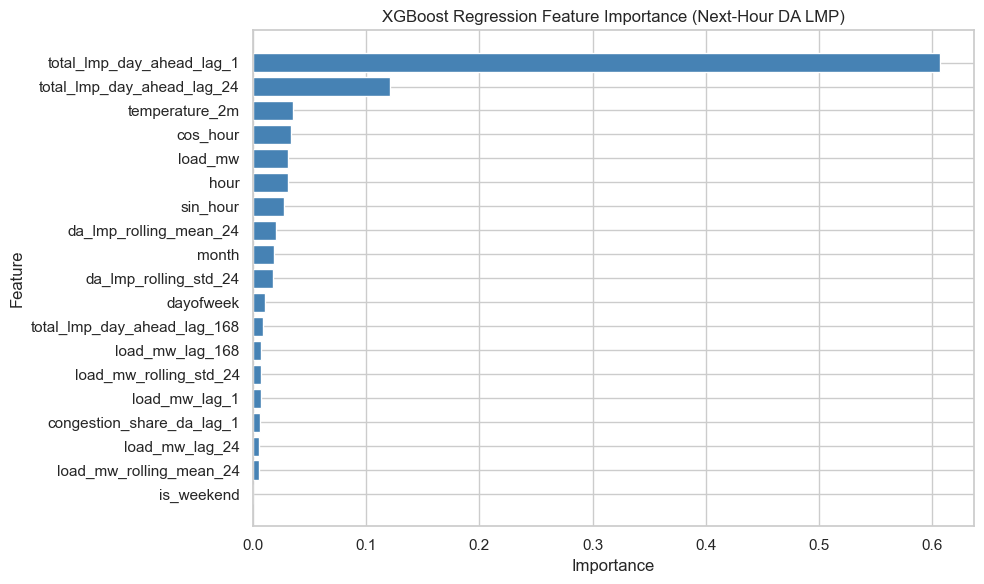

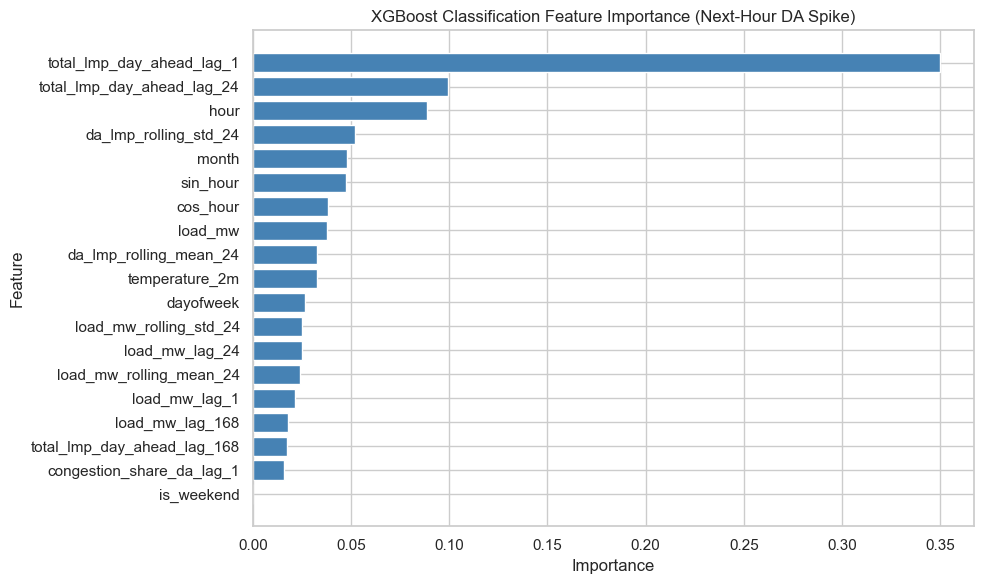

Top XGBoost regression features:
                   feature  importance
 total_lmp_day_ahead_lag_1    0.606476
total_lmp_day_ahead_lag_24    0.120781
            temperature_2m    0.035050
                  cos_hour    0.033300
                   load_mw    0.031044
                      hour    0.030689
                  sin_hour    0.027173
    da_lmp_rolling_mean_24    0.020254
                     month    0.018492
     da_lmp_rolling_std_24    0.018103
Top XGBoost classification features:
                   feature  importance
 total_lmp_day_ahead_lag_1    0.349731
total_lmp_day_ahead_lag_24    0.099519
                      hour    0.088457
     da_lmp_rolling_std_24    0.052126
                     month    0.048073
                  sin_hour    0.047672
                  cos_hour    0.038262
                   load_mw    0.037494
    da_lmp_rolling_mean_24    0.032758
            temperature_2m    0.032411
shap is not installed in this environment. Install shap to generate SHAP

In [126]:
def plot_feature_importance(model, feature_names, title):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()

plot_feature_importance(reg_model, regression_features, 'XGBoost Regression Feature Importance (Next-Hour DA LMP)')
plot_feature_importance(cls_model, cls_features, 'XGBoost Classification Feature Importance (Next-Hour DA Spike)')

importance_reg = pd.DataFrame({
    'feature': regression_features,
    'importance': reg_model.feature_importances_
}).sort_values('importance', ascending=False)

importance_cls = pd.DataFrame({
    'feature': cls_features,
    'importance': cls_model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top XGBoost regression features:')
print(importance_reg.head(10).to_string(index=False))
print('Top XGBoost classification features:')
print(importance_cls.head(10).to_string(index=False))

try:
    import shap
    explainer = shap.TreeExplainer(reg_model)
    shap_values = explainer.shap_values(X_test_reg)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_reg, feature_names=regression_features, plot_type='bar', show=False)
    plt.title('SHAP Summary - XGBoost Regression (Next-Hour DA LMP)')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('shap is not installed in this environment. Install shap to generate SHAP interpretability outputs.')

## Spike Classification Confusion Matrix

Evaluate the next-hour day-ahead price spike classifier with a confusion matrix. This helps distinguish missed spike events from false alarms, which is important for market risk monitoring.

Confusion matrix for next-hour DA price spike prediction:
                 Predicted No Spike  Predicted Spike
Actual No Spike                2075               34
Actual Spike                    100               91

True negatives: 2075
False positives: 34
False negatives: 100
True positives: 91
False alarm rate: 0.016
Missed spike rate: 0.524


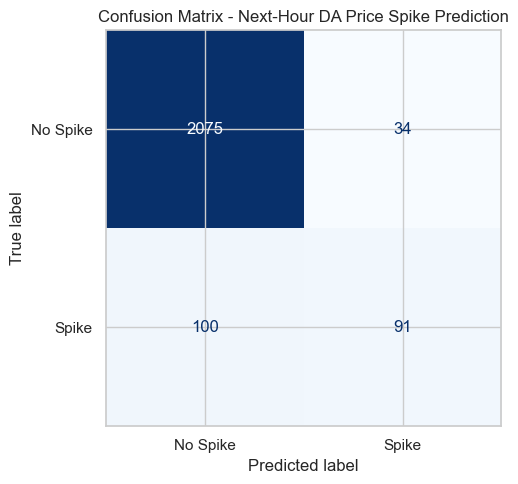

In [127]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_cls, y_pred_cls)
cm_df = pd.DataFrame(
    cm,
    index=['Actual No Spike', 'Actual Spike'],
    columns=['Predicted No Spike', 'Predicted Spike']
)

print('Confusion matrix for next-hour DA price spike prediction:')
print(cm_df.to_string())

tn, fp, fn, tp = cm.ravel()
print()
print(f'True negatives: {tn}')
print(f'False positives: {fp}')
print(f'False negatives: {fn}')
print(f'True positives: {tp}')
print(f'False alarm rate: {fp / (fp + tn):.3f}' if (fp + tn) > 0 else 'False alarm rate: N/A')
print(f'Missed spike rate: {fn / (fn + tp):.3f}' if (fn + tp) > 0 else 'Missed spike rate: N/A')

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Spike', 'Spike']
)
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - Next-Hour DA Price Spike Prediction')
plt.tight_layout()
plt.show()


## Spike Recall Tuning Experiments

Try threshold tuning and class weighting for imbalanced spike classification. The final displayed model is the default XGBoost classifier with a tuned threshold, selected because it catches more true spike events and reduces missed spikes, which is useful for price-risk monitoring.

Spike classifier tuning comparison:
                             model  threshold  accuracy  precision  recall    f1  pr_auc   tn  fp  fn  tp
            Default XGBoost @ 0.50       0.50     0.942      0.728   0.476 0.576   0.668 2075  34 100  91
 Default XGBoost @ tuned threshold       0.44     0.942      0.711   0.503 0.589   0.668 2070  39  95  96
           Weighted XGBoost @ 0.50       0.50     0.935      0.616   0.571 0.592   0.681 2041  68  82 109
Weighted XGBoost @ tuned threshold       0.79     0.946      0.770   0.492 0.601   0.681 2081  28  97  94

scale_pos_weight used for weighted model: 22.46


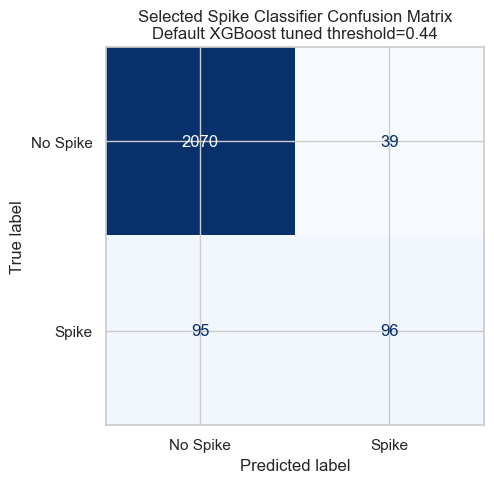


Selected model metrics:
threshold: 0.440
accuracy: 0.942
precision: 0.711
recall: 0.503
f1: 0.589
pr_auc: 0.668
tn: 2070
fp: 39
fn: 95
tp: 96

Selected confusion matrix:
                 Predicted No Spike  Predicted Spike
Actual No Spike                2070               39
Actual Spike                     95               96


In [128]:
from sklearn.metrics import average_precision_score


def evaluate_spike_model(name, y_true, y_prob, threshold=0.50):
    y_hat = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    tn, fp, fn, tp = cm.ravel()
    return {
        'model': name,
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_hat),
        'precision': precision_score(y_true, y_hat, zero_division=0),
        'recall': recall_score(y_true, y_hat, zero_division=0),
        'f1': f1_score(y_true, y_hat, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_prob),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
    }


def find_best_threshold(y_true, y_prob, metric='f1'):
    thresholds = np.arange(0.05, 0.96, 0.01)
    rows = []
    for threshold in thresholds:
        row = evaluate_spike_model('threshold_search', y_true, y_prob, threshold)
        rows.append(row)
    threshold_df = pd.DataFrame(rows)
    best_idx = threshold_df[metric].idxmax()
    return threshold_df.loc[best_idx], threshold_df


def plot_confusion_for_config(y_true, y_prob, threshold, title):
    y_hat = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Spike', 'Spike']
    ).plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm

# Baseline classifier probabilities from the existing model.
y_prob_default = cls_model.predict_proba(X_test_cls)[:, 1]
best_default_threshold, default_threshold_grid = find_best_threshold(y_test_cls, y_prob_default, metric='f1')

# Class weighting is evaluated as a comparison, but the final displayed model keeps the default model
# with a tuned threshold because it captures more true spike events for risk monitoring.
pos_count = y_train_cls.sum()
neg_count = len(y_train_cls) - pos_count
scale_pos_weight = neg_count / pos_count

weighted_cls_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0,
    scale_pos_weight=scale_pos_weight,
)
weighted_cls_model.fit(X_train_cls, y_train_cls)
y_prob_weighted = weighted_cls_model.predict_proba(X_test_cls)[:, 1]
best_weighted_threshold, weighted_threshold_grid = find_best_threshold(y_test_cls, y_prob_weighted, metric='f1')

spike_tuning_results = pd.DataFrame([
    evaluate_spike_model('Default XGBoost @ 0.50', y_test_cls, y_prob_default, threshold=0.50),
    evaluate_spike_model('Default XGBoost @ tuned threshold', y_test_cls, y_prob_default, threshold=best_default_threshold['threshold']),
    evaluate_spike_model('Weighted XGBoost @ 0.50', y_test_cls, y_prob_weighted, threshold=0.50),
    evaluate_spike_model('Weighted XGBoost @ tuned threshold', y_test_cls, y_prob_weighted, threshold=best_weighted_threshold['threshold']),
])

metric_cols = ['model', 'threshold', 'accuracy', 'precision', 'recall', 'f1', 'pr_auc', 'tn', 'fp', 'fn', 'tp']
print('Spike classifier tuning comparison:')
print(spike_tuning_results[metric_cols].round(3).to_string(index=False))
print()
print(f'scale_pos_weight used for weighted model: {scale_pos_weight:.2f}')

# Final selected display: default XGBoost with tuned threshold.
# This version prioritizes catching more real spike events, which is useful for risk monitoring.
selected_threshold = best_default_threshold['threshold']
selected_cm = plot_confusion_for_config(
    y_test_cls,
    y_prob_default,
    selected_threshold,
    f'Selected Spike Classifier Confusion Matrix\nDefault XGBoost tuned threshold={selected_threshold:.2f}'
)
selected_metrics = evaluate_spike_model(
    'Selected: Default XGBoost tuned threshold',
    y_test_cls,
    y_prob_default,
    threshold=selected_threshold
)

print()
print('Selected model metrics:')
for key in ['threshold', 'accuracy', 'precision', 'recall', 'f1', 'pr_auc', 'tn', 'fp', 'fn', 'tp']:
    value = selected_metrics[key]
    print(f'{key}: {value:.3f}' if isinstance(value, float) else f'{key}: {value}')

print()
print('Selected confusion matrix:')
print(pd.DataFrame(
    selected_cm,
    index=['Actual No Spike', 'Actual Spike'],
    columns=['Predicted No Spike', 'Predicted Spike']
).to_string())


## Lag Price Feature Ablation Experiment

Compare the current next-hour DA LMP model against a no-price-lag version to test how much forecast skill comes from recent LMP history. Model A uses the full feature set. Model B removes all features whose names contain `lmp`, following `regression_features_no_lag = [f for f in regression_features if 'lmp' not in f]`.


Removed LMP history features:
['total_lmp_day_ahead_lag_1', 'total_lmp_day_ahead_lag_24', 'total_lmp_day_ahead_lag_168', 'da_lmp_rolling_mean_24', 'da_lmp_rolling_std_24']
Model A feature count: 19
Model B feature count: 14
Ablation metrics:
                             MAE    RMSE  Safe MAPE (abs > 1)  MAE_change_vs_A  MAE_change_vs_A_%
Model A: full features     6.505  10.798               13.287            0.000              0.000
Model B: no LMP features  14.705  19.573               30.860            8.199            126.044
Top Model A regression features:
                   feature  importance
 total_lmp_day_ahead_lag_1    0.606476
total_lmp_day_ahead_lag_24    0.120781
            temperature_2m    0.035050
                  cos_hour    0.033300
                   load_mw    0.031044
                      hour    0.030689
                  sin_hour    0.027173
    da_lmp_rolling_mean_24    0.020254
                     month    0.018492
     da_lmp_rolling_std_24    0.018103
To

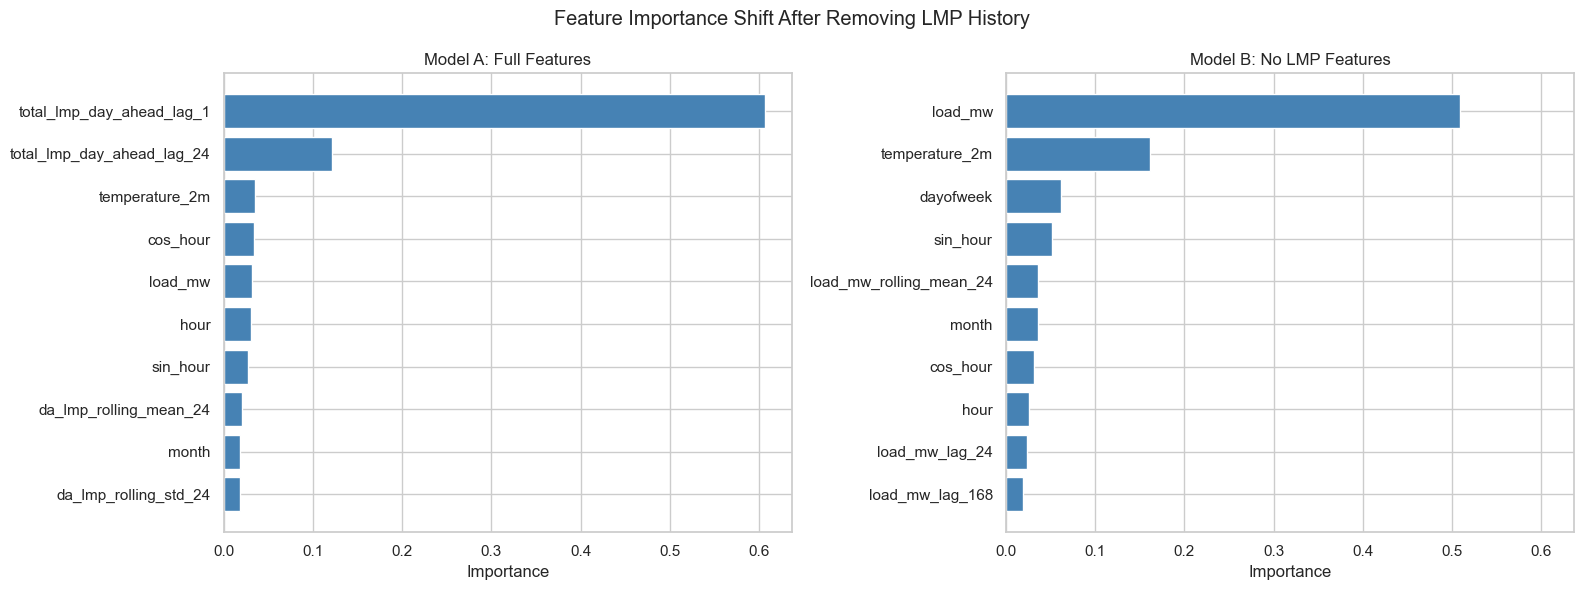

In [129]:
regression_features_no_lag = [f for f in regression_features if 'lmp' not in f]
removed_lmp_features = [f for f in regression_features if f not in regression_features_no_lag]

print('Removed LMP history features:')
print(removed_lmp_features)
print(f'Model A feature count: {len(regression_features)}')
print(f'Model B feature count: {len(regression_features_no_lag)}')

def train_ablation_regressor(features):
    model = XGBRegressor(
        n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1, verbosity=0
    )
    model.fit(train_df[features], y_train_reg)
    preds = model.predict(test_df[features])

    mask = np.abs(y_test_reg) > 1
    metrics = {
        'MAE': mean_absolute_error(y_test_reg, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, preds)),
        'Safe MAPE (abs > 1)': np.mean(np.abs((y_test_reg[mask] - preds[mask]) / y_test_reg[mask])) * 100 if mask.any() else np.nan
    }
    importance = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    return model, preds, metrics, importance

model_a, pred_a, metrics_a, importance_a = train_ablation_regressor(regression_features)
model_b, pred_b, metrics_b, importance_b = train_ablation_regressor(regression_features_no_lag)

ablation_metrics = pd.DataFrame([metrics_a, metrics_b], index=['Model A: full features', 'Model B: no LMP features'])
ablation_metrics['MAE_change_vs_A'] = ablation_metrics['MAE'] - ablation_metrics.loc['Model A: full features', 'MAE']
ablation_metrics['MAE_change_vs_A_%'] = (
    ablation_metrics['MAE'] / ablation_metrics.loc['Model A: full features', 'MAE'] - 1
) * 100

print('Ablation metrics:')
print(ablation_metrics.round(3).to_string())

print('Top Model A regression features:')
print(importance_a.head(10).to_string(index=False))
print('Top Model B regression features:')
print(importance_b.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for ax, importance_df, title in [
    (axes[0], importance_a.head(10), 'Model A: Full Features'),
    (axes[1], importance_b.head(10), 'Model B: No LMP Features')
]:
    ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Importance')

fig.suptitle('Feature Importance Shift After Removing LMP History')
plt.tight_layout()
plt.show()


## LMP Forecast Benchmark Table

Compare the next-hour day-ahead LMP model against a simple price persistence benchmark and the no-LMP-history ablation model. This separates basic market persistence from the added value of engineered features. In very short-horizon power price forecasting, persistence can be extremely hard to beat, so this benchmark is an important reality check rather than a throwaway baseline.

LMP forecast benchmark table:
                                MAE    RMSE  Safe MAPE (abs > 1)  MAE_improvement_vs_persistence_%
Persistence: current DA LMP   5.732  10.480               11.355                             0.000
XGBoost: full features        6.505  10.798               13.287                           -13.483
XGBoost: no LMP history      14.705  19.573               30.860                          -156.521


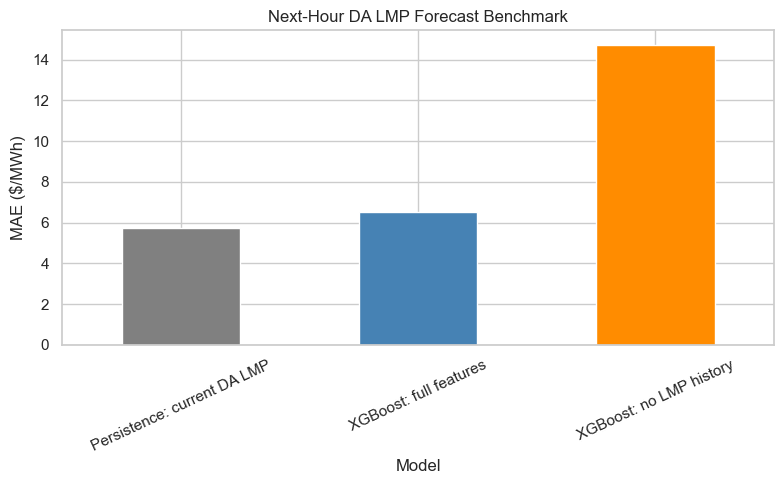

In [130]:
persistence_pred = test_df['total_lmp_day_ahead']
mask = np.abs(y_test_reg) > 1

persistence_metrics = {
    'MAE': mean_absolute_error(y_test_reg, persistence_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, persistence_pred)),
    'Safe MAPE (abs > 1)': np.mean(np.abs((y_test_reg[mask] - persistence_pred[mask]) / y_test_reg[mask])) * 100 if mask.any() else np.nan
}

lmp_benchmark_df = pd.DataFrame(
    [persistence_metrics, metrics_a, metrics_b],
    index=['Persistence: current DA LMP', 'XGBoost: full features', 'XGBoost: no LMP history']
)
lmp_benchmark_df['MAE_improvement_vs_persistence_%'] = (
    (lmp_benchmark_df.loc['Persistence: current DA LMP', 'MAE'] - lmp_benchmark_df['MAE'])
    / lmp_benchmark_df.loc['Persistence: current DA LMP', 'MAE']
    * 100
)

print('LMP forecast benchmark table:')
print(lmp_benchmark_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
lmp_benchmark_df['MAE'].plot(kind='bar', color=['gray', 'steelblue', 'darkorange'], ax=ax)
ax.set_title('Next-Hour DA LMP Forecast Benchmark')
ax.set_ylabel('MAE ($/MWh)')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


## Diagnostics

Visualize model performance, next-hour spike prediction behavior, load-LMP relationships, hourly price profiles, and congestion component dynamics. These charts are designed for practical market monitoring and decision support.

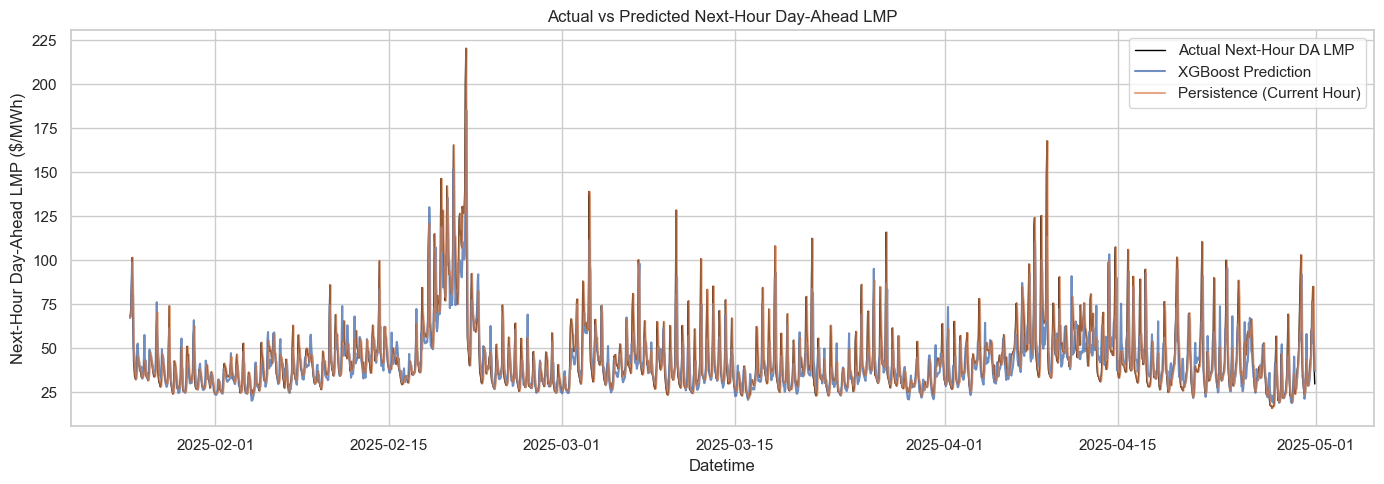

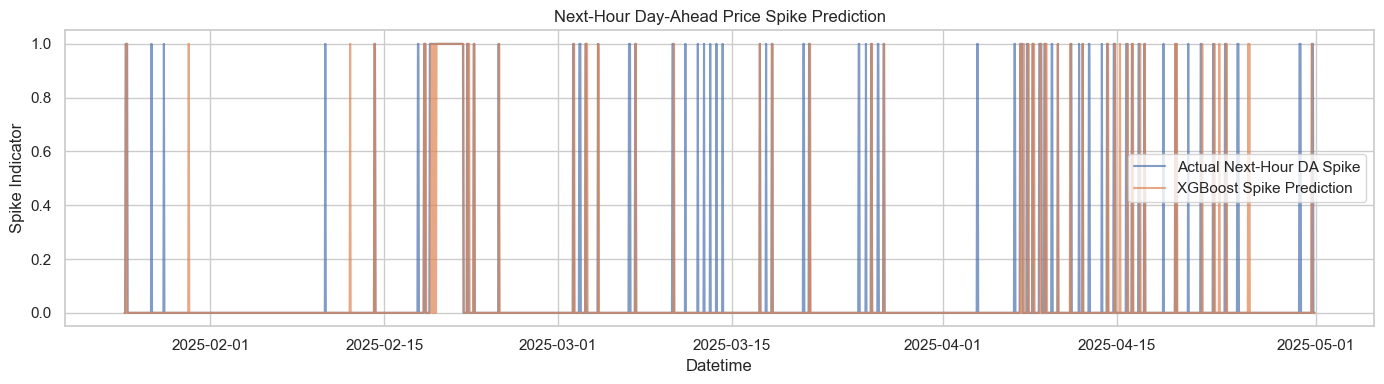

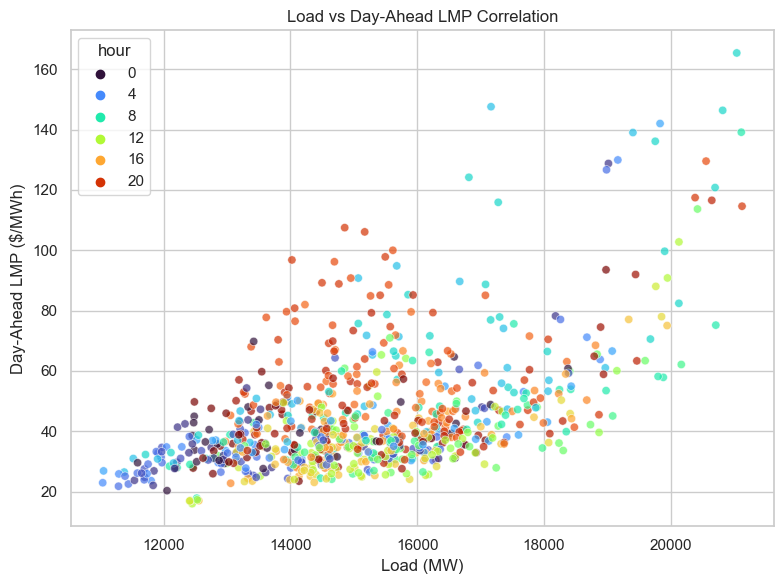

/Users/wangzhuoran/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wangzhuoran/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


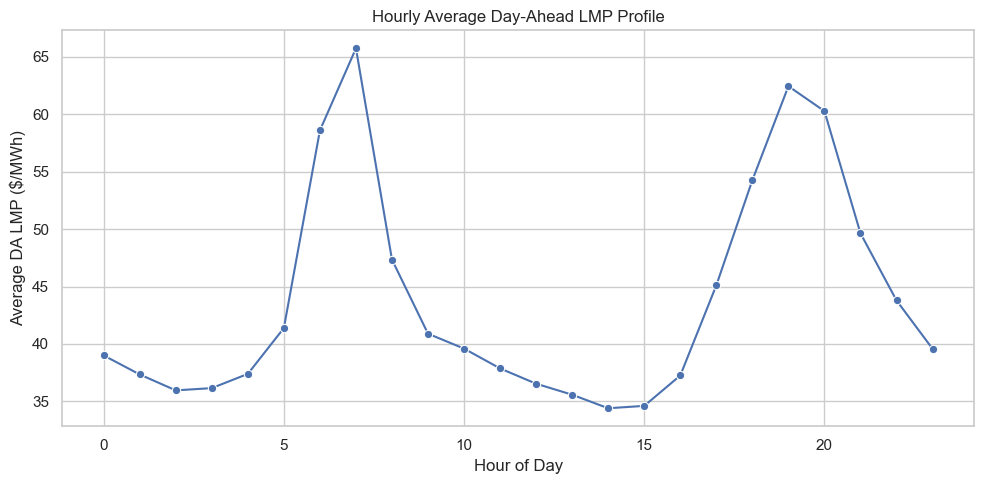

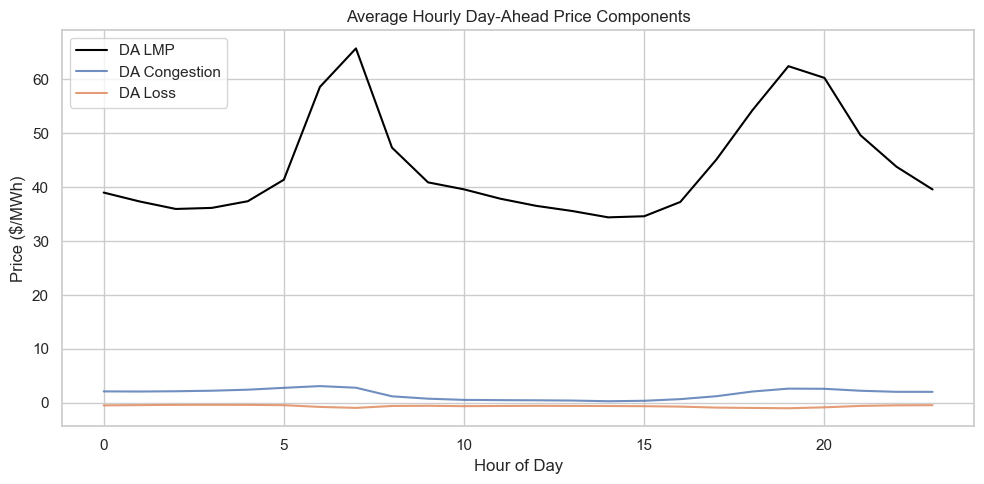

In [131]:
visual_df = test_df[['datetime', 'target_da_lmp_next_hour']].copy()
visual_df = visual_df.rename(columns={'target_da_lmp_next_hour': 'Actual_Next_Hour_DA_LMP'})
visual_df['XGBoost_Prediction'] = y_pred_reg
visual_df['Persistence'] = test_df['total_lmp_day_ahead']  # Use current hour DA LMP as persistence baseline for next-hour prediction

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(visual_df['datetime'], visual_df['Actual_Next_Hour_DA_LMP'], label='Actual Next-Hour DA LMP', color='black', linewidth=1)
ax.plot(visual_df['datetime'], visual_df['XGBoost_Prediction'], label='XGBoost Prediction', alpha=0.8)
ax.plot(visual_df['datetime'], visual_df['Persistence'], label='Persistence (Current Hour)', alpha=0.7)
ax.set_title('Actual vs Predicted Next-Hour Day-Ahead LMP')
ax.set_xlabel('Datetime')
ax.set_ylabel('Next-Hour Day-Ahead LMP ($/MWh)')
ax.legend()
plt.tight_layout()
plt.show()

spike_df = test_df[['datetime', 'target_da_spike_next_hour']].copy()
spike_df['Prediction'] = y_pred_cls
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spike_df['datetime'], spike_df['target_da_spike_next_hour'], label='Actual Next-Hour DA Spike', alpha=0.7)
ax.plot(spike_df['datetime'], spike_df['Prediction'], label='XGBoost Spike Prediction', alpha=0.7)
ax.set_title('Next-Hour Day-Ahead Price Spike Prediction')
ax.set_xlabel('Datetime')
ax.set_ylabel('Spike Indicator')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x='load_mw',
    y='total_lmp_day_ahead',
    hue='hour',
    palette='turbo',
    data=test_df.sample(n=min(800, len(test_df)), random_state=42),
    alpha=0.7,
    ax=ax
)
ax.set_title('Load vs Day-Ahead LMP Correlation')
ax.set_xlabel('Load (MW)')
ax.set_ylabel('Day-Ahead LMP ($/MWh)')
plt.tight_layout()
plt.show()

hourly_profile = test_df.groupby('hour')['total_lmp_day_ahead'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=hourly_profile, x='hour', y='total_lmp_day_ahead', marker='o', ax=ax)
ax.set_title('Hourly Average Day-Ahead LMP Profile')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average DA LMP ($/MWh)')
plt.tight_layout()
plt.show()

congestion_profile = test_df.groupby('hour')[['congestion_price_day_ahead', 'marginal_loss_price_day_ahead', 'total_lmp_day_ahead']].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(congestion_profile['hour'], congestion_profile['total_lmp_day_ahead'], label='DA LMP', color='black')
ax.plot(congestion_profile['hour'], congestion_profile['congestion_price_day_ahead'], label='DA Congestion', alpha=0.8)
ax.plot(congestion_profile['hour'], congestion_profile['marginal_loss_price_day_ahead'], label='DA Loss', alpha=0.8)
ax.set_title('Average Hourly Day-Ahead Price Components')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Price ($/MWh)')
ax.legend()
plt.tight_layout()
plt.show()

## Spike Timing and Load Analysis

Analyze when day-ahead price spikes occur in the held-out test period and whether they cluster at higher load levels.

DA price spike count by hour in test set:
hour
0      4
1      3
2      3
3      3
4      3
5      5
6     24
7     32
8      8
9      5
10     3
11     2
12     2
13     2
14     2
15     2
16     2
17     4
18    12
19    30
20    25
21     7
22     4
23     4
Name: count, dtype: int64


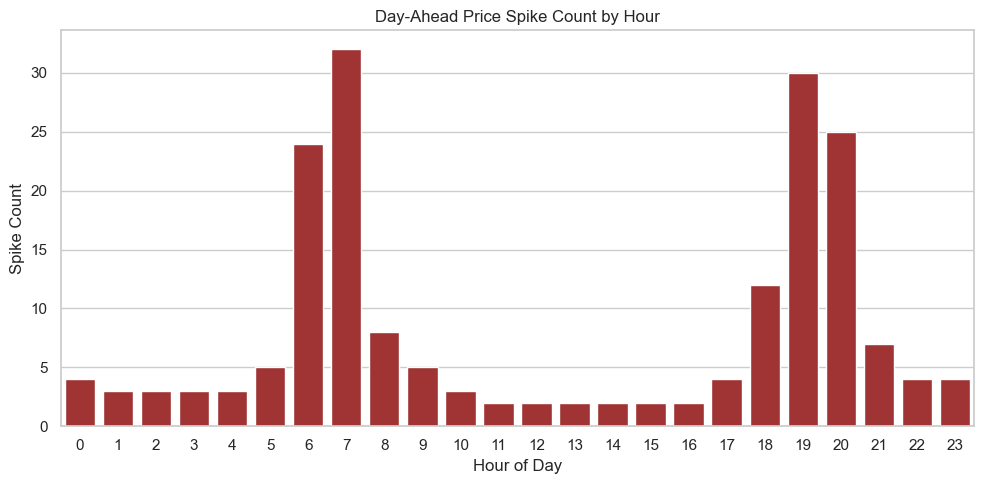

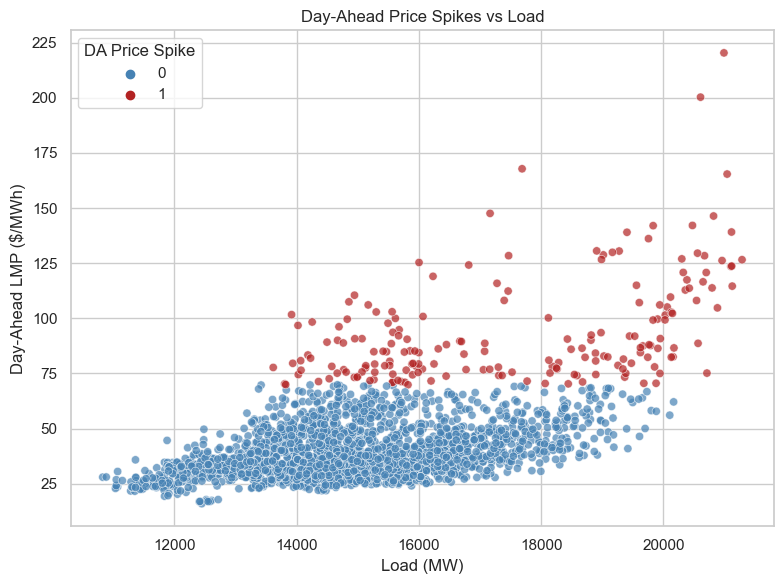

In [132]:
spike_hours = test_df[test_df['da_price_spike'] == 1]

print('DA price spike count by hour in test set:')
print(spike_hours['hour'].value_counts().sort_index())

spike_hour_counts = (
    spike_hours['hour']
    .value_counts()
    .sort_index()
    .reindex(range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=spike_hour_counts.index, y=spike_hour_counts.values, color='firebrick', ax=ax)
ax.set_title('Day-Ahead Price Spike Count by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Spike Count')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=test_df,
    x='load_mw',
    y='total_lmp_day_ahead',
    hue='da_price_spike',
    palette={0: 'steelblue', 1: 'firebrick'},
    alpha=0.7,
    ax=ax
)
ax.set_title('Day-Ahead Price Spikes vs Load')
ax.set_xlabel('Load (MW)')
ax.set_ylabel('Day-Ahead LMP ($/MWh)')
ax.legend(title='DA Price Spike')
plt.tight_layout()
plt.show()


## Congestion and Price Stress Analysis

Compare congestion, losses, RT-DA spread, and load during spike versus non-spike hours. This provides a market interpretation layer beyond pure forecast accuracy.

Congestion and spread profile by DA price spike flag:
               total_lmp_day_ahead                 congestion_price_day_ahead               marginal_loss_price_day_ahead               rt_da_spread                    load_mw                     
                              mean  median     std                       mean median    std                          mean median    std         mean  median     std       mean     median       std
da_price_spike                                                                                                                                                                                      
0                           39.255  36.932  10.966                      1.568  1.187  2.515                        -0.554 -0.514  0.532        0.722  -2.123  15.791  14996.476  14893.766  1716.302
1                           93.872  86.001  23.919                      2.871  2.656  5.446                        -1.073 -0.974  1.108       -7.247 -12.620  

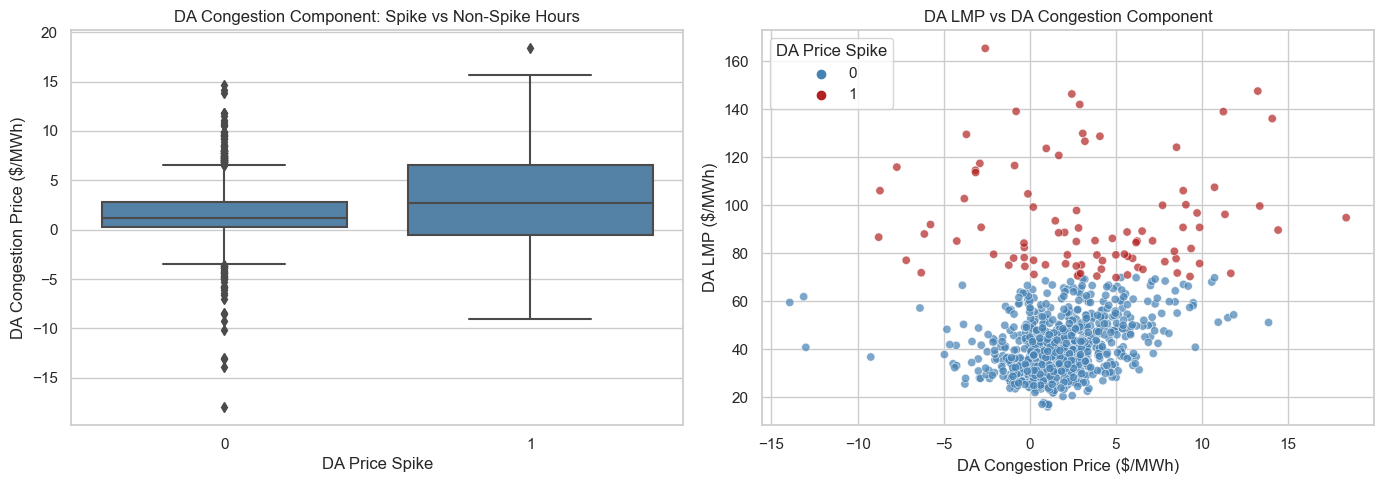

In [133]:
congestion_stress_summary = test_df.groupby('da_price_spike')[[
    'total_lmp_day_ahead',
    'congestion_price_day_ahead',
    'marginal_loss_price_day_ahead',
    'rt_da_spread',
    'load_mw'
]].agg(['mean', 'median', 'std'])

print('Congestion and spread profile by DA price spike flag:')
print(congestion_stress_summary.round(3).to_string())

correlation_cols = [
    'total_lmp_day_ahead',
    'congestion_price_day_ahead',
    'marginal_loss_price_day_ahead',
    'rt_da_spread',
    'load_mw'
]
congestion_corr = test_df[correlation_cols].corr()
print()
print('Correlation between price, congestion, spread, and load:')
print(congestion_corr.round(3).to_string())

extreme_spread_threshold = test_df['rt_da_spread'].abs().quantile(0.90)
extreme_spread_df = test_df[test_df['rt_da_spread'].abs() >= extreme_spread_threshold]
print()
print(f'Extreme RT-DA spread threshold, 90th percentile absolute spread: {extreme_spread_threshold:.2f} $/MWh')
print('Average market conditions during extreme RT-DA spread periods:')
print(extreme_spread_df[[
    'total_lmp_day_ahead',
    'total_lmp_real_time',
    'congestion_price_day_ahead',
    'marginal_loss_price_day_ahead',
    'rt_da_spread',
    'load_mw'
]].mean().round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=test_df,
    x='da_price_spike',
    y='congestion_price_day_ahead',
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('DA Congestion Component: Spike vs Non-Spike Hours')
axes[0].set_xlabel('DA Price Spike')
axes[0].set_ylabel('DA Congestion Price ($/MWh)')

sns.scatterplot(
    data=test_df.sample(n=min(1000, len(test_df)), random_state=42),
    x='congestion_price_day_ahead',
    y='total_lmp_day_ahead',
    hue='da_price_spike',
    palette={0: 'steelblue', 1: 'firebrick'},
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('DA LMP vs DA Congestion Component')
axes[1].set_xlabel('DA Congestion Price ($/MWh)')
axes[1].set_ylabel('DA LMP ($/MWh)')
axes[1].legend(title='DA Price Spike')

plt.tight_layout()
plt.show()


## Simple Trading Signal

Build a lightweight spread signal from the day-ahead and real-time price relationship. Spread signals can be used to identify short-term arbitrage or hedging opportunities.

Spread signal threshold (90th percentile absolute spread): 23.77 $/MWh
Signal direction counts:
signal_direction
Neutral                            2070
RT premium / potential DA hedge     143
DA premium / potential RT hedge      87
Largest absolute spread signals:
           datetime  hour  total_lmp_day_ahead  total_lmp_real_time  spread_signal  pred_spread   load_mw                signal_direction
2025-04-08 07:00:00     7           124.197304           918.578577     794.381273   -13.761894 16815.879 RT premium / potential DA hedge
2025-02-05 10:00:00    10            50.727441           297.504302     246.776861    -9.813996 17529.897 RT premium / potential DA hedge
2025-04-23 16:00:00    16            41.616604           210.177489     168.560885    12.592819 15406.405 RT premium / potential DA hedge
2025-02-06 10:00:00    10            41.742762           162.891866     121.149104    -0.207312 17279.206 RT premium / potential DA hedge
2025-02-11 09:00:00     9            53.7756

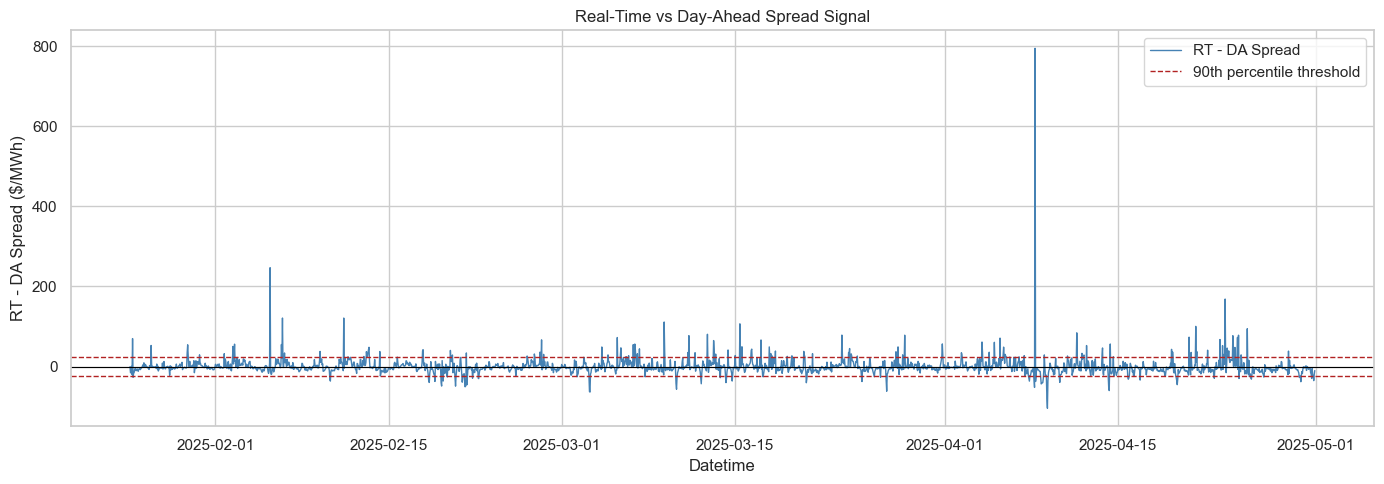

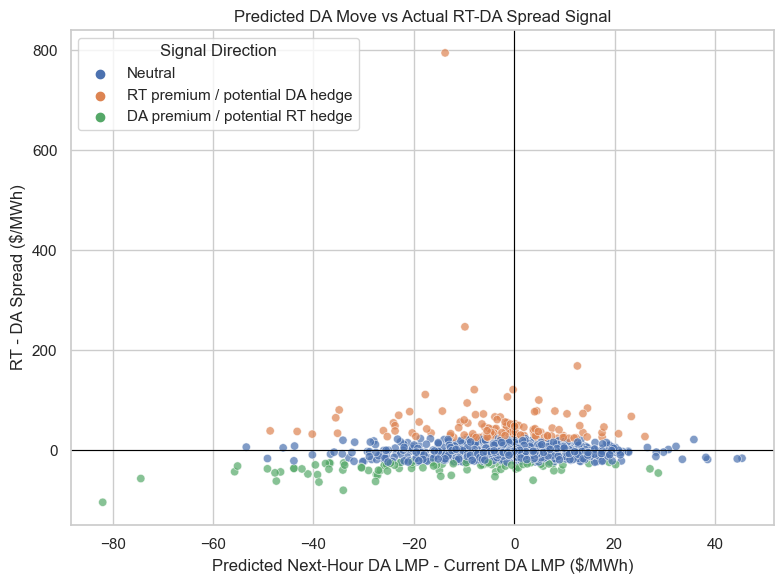

In [134]:
signal_df = test_df[['datetime', 'hour', 'total_lmp_day_ahead', 'total_lmp_real_time', 'rt_da_spread', 'load_mw']].copy()
signal_df['pred_next_hour_da_lmp'] = y_pred_reg
signal_df['pred_spread'] = signal_df['pred_next_hour_da_lmp'] - signal_df['total_lmp_day_ahead']
signal_df['spread_signal'] = signal_df['rt_da_spread']

spread_threshold = signal_df['spread_signal'].abs().quantile(0.90)
signal_df['signal_direction'] = np.select(
    [
        signal_df['spread_signal'] >= spread_threshold,
        signal_df['spread_signal'] <= -spread_threshold
    ],
    ['RT premium / potential DA hedge', 'DA premium / potential RT hedge'],
    default='Neutral'
)

print(f'Spread signal threshold (90th percentile absolute spread): {spread_threshold:.2f} $/MWh')
print('Signal direction counts:')
print(signal_df['signal_direction'].value_counts().to_string())

print('Largest absolute spread signals:')
print(
    signal_df.assign(abs_spread_signal=signal_df['spread_signal'].abs())
    .sort_values('abs_spread_signal', ascending=False)
    [['datetime', 'hour', 'total_lmp_day_ahead', 'total_lmp_real_time', 'spread_signal', 'pred_spread', 'load_mw', 'signal_direction']]
    .head(10)
    .to_string(index=False)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(signal_df['datetime'], signal_df['spread_signal'], label='RT - DA Spread', color='steelblue', linewidth=1)
ax.axhline(spread_threshold, color='firebrick', linestyle='--', linewidth=1, label='90th percentile threshold')
ax.axhline(-spread_threshold, color='firebrick', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Real-Time vs Day-Ahead Spread Signal')
ax.set_xlabel('Datetime')
ax.set_ylabel('RT - DA Spread ($/MWh)')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=signal_df,
    x='pred_spread',
    y='spread_signal',
    hue='signal_direction',
    alpha=0.7,
    ax=ax
)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Predicted DA Move vs Actual RT-DA Spread Signal')
ax.set_xlabel('Predicted Next-Hour DA LMP - Current DA LMP ($/MWh)')
ax.set_ylabel('RT - DA Spread ($/MWh)')
ax.legend(title='Signal Direction')
plt.tight_layout()
plt.show()


## Market Interpretation

The results show that next-hour day-ahead LMP is highly persistent, with lag-1 and lag-24 prices emerging as the strongest predictors in the XGBoost models. This suggests that electricity prices exhibit both short-term momentum and strong daily seasonality.

Hourly pricing patterns reveal clear peaks during late afternoon and early evening hours, consistent with periods of higher demand and tighter system conditions. At higher load levels, price dispersion also increases noticeably, indicating elevated volatility and greater spike risk during stressed market conditions.

Feature importance results further show that time-of-day structure and recent price behavior dominate short-horizon forecasting performance. While load and temperature contribute to price formation, part of their signal appears to be embedded in recent market prices.

The spike classification results suggest that extreme price events are more closely associated with volatility and system stress than with average operating conditions. Congestion components and higher load levels are more common during spike periods, supporting the interpretation that constrained system conditions contribute to short-term price stress.

From an operational perspective, the workflow can support short-horizon exposure monitoring, spike-risk identification, and market condition tracking during volatile periods. More broadly, the project demonstrates how time-series-safe feature engineering and interpretable machine learning models can be applied to electricity market forecasting and analytics.


## Export Dashboard Outputs

Save the LMP forecasting, spike classification, congestion, and spread-signal artifacts to `outputs/` for the portfolio dashboard and GitHub README.

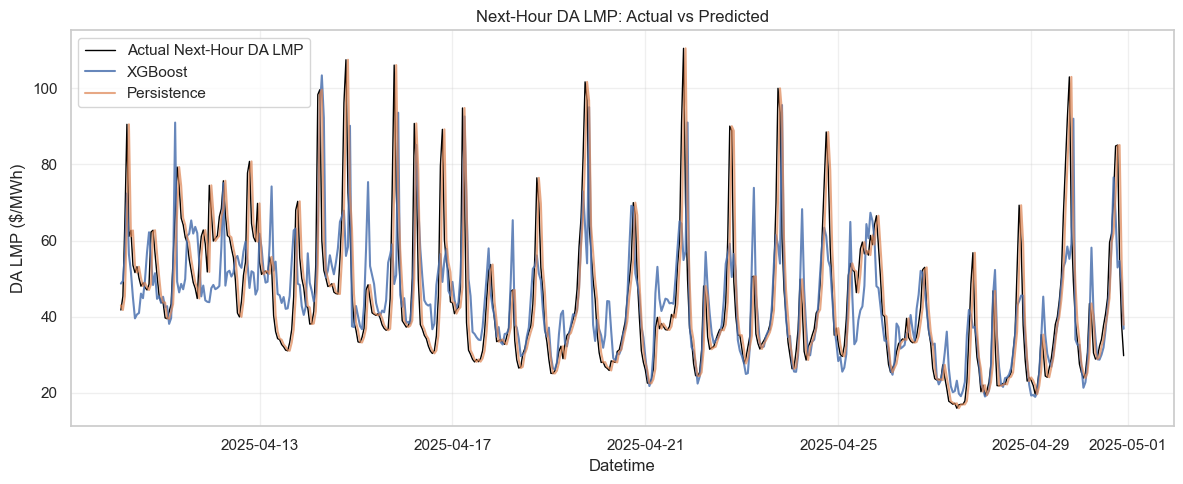

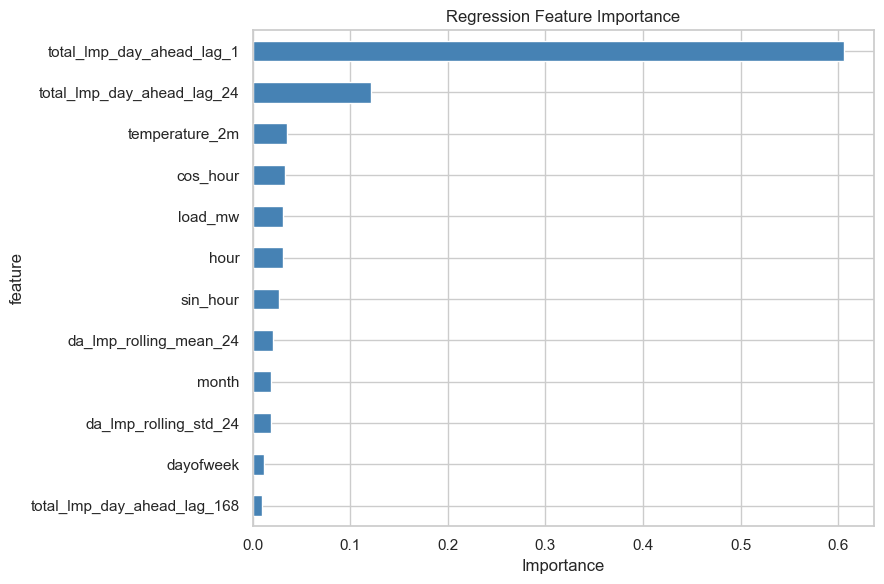

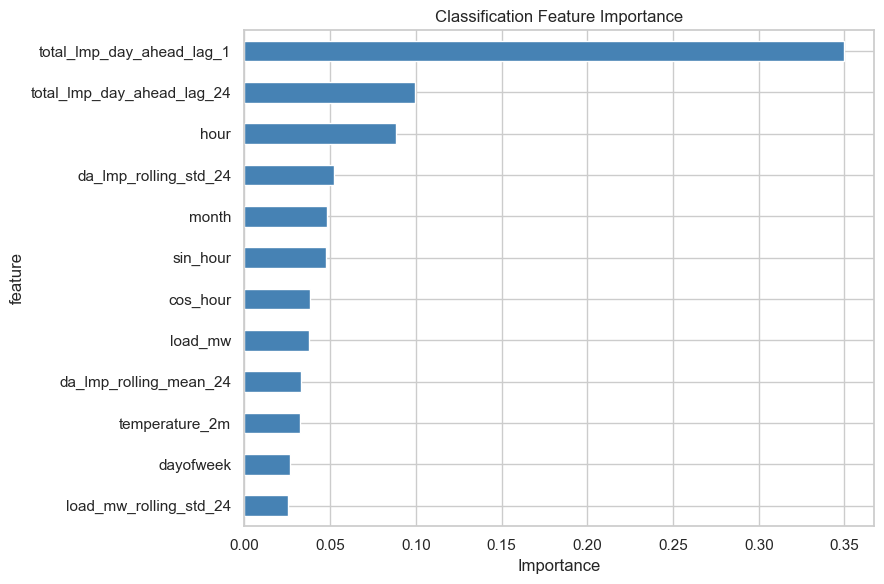

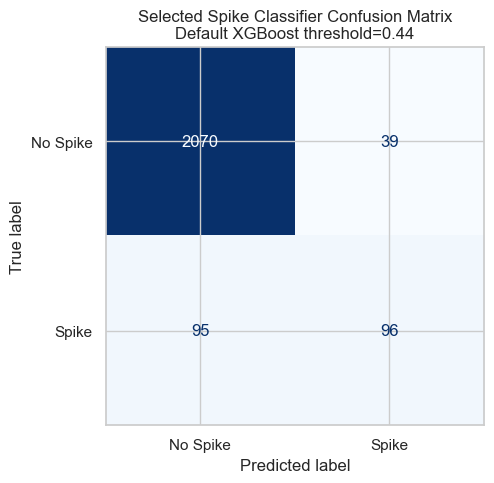

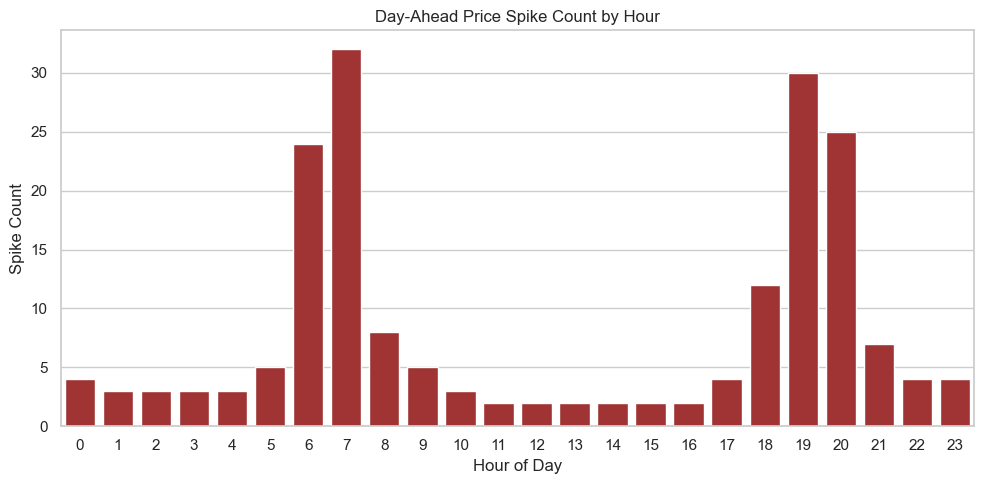

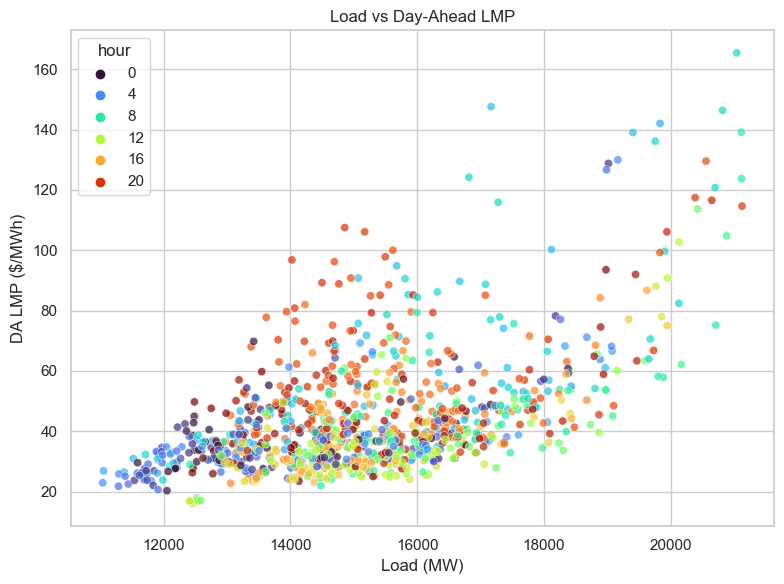

/Users/wangzhuoran/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wangzhuoran/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


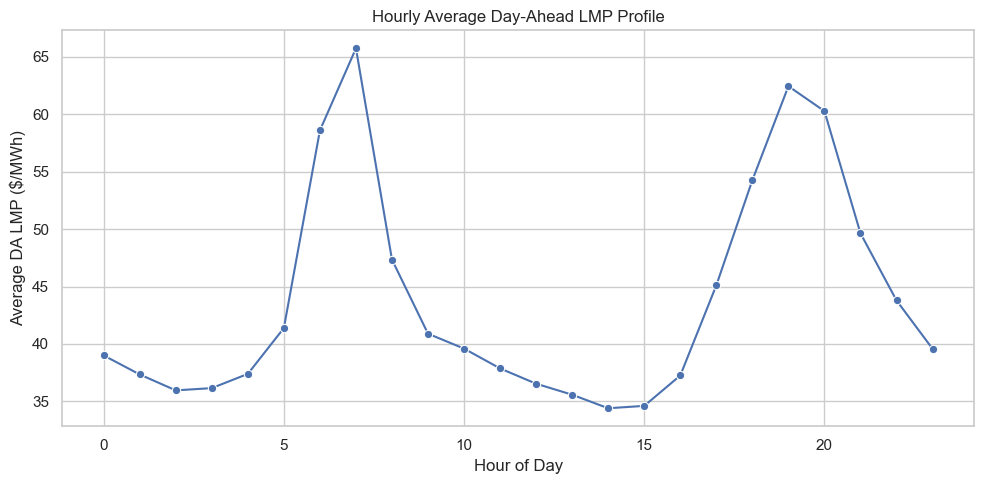

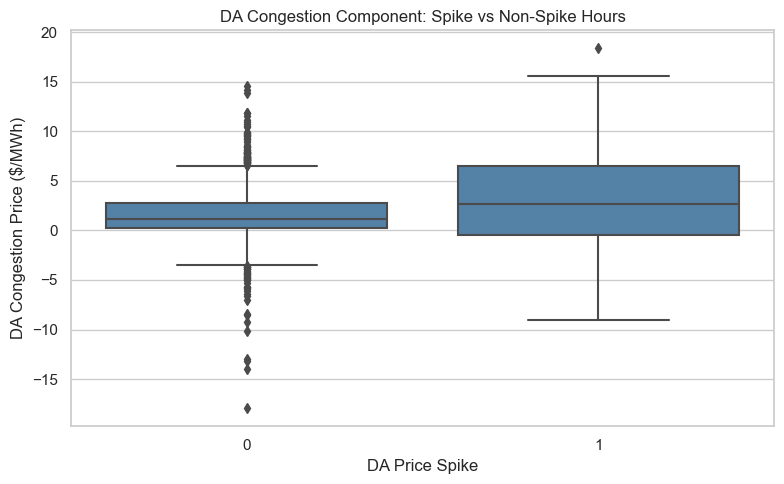

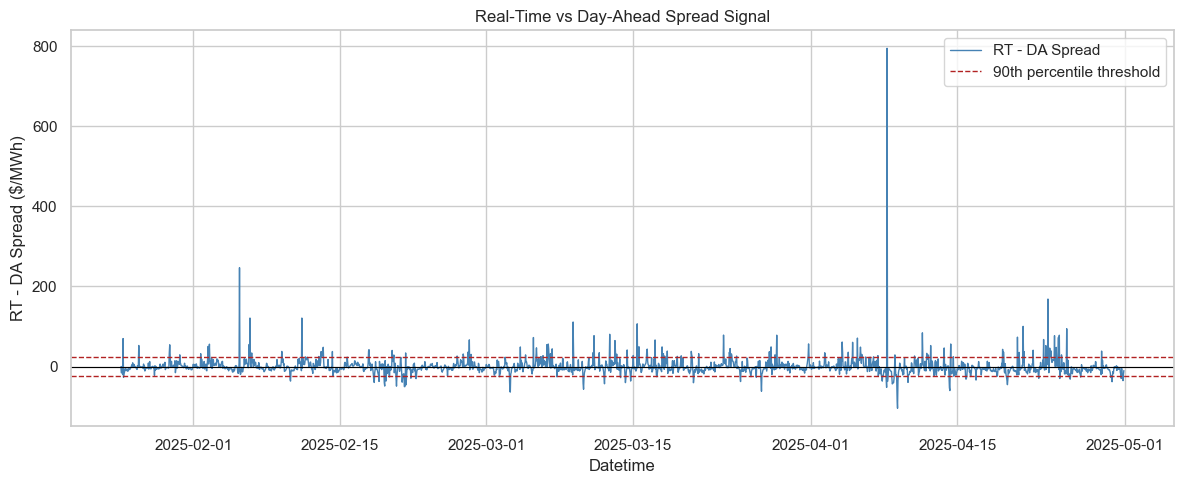

Saved LMP dashboard outputs to /Users/wangzhuoran/Desktop/pjm-energy-market-forecasting/outputs


In [136]:
from pathlib import Path

output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

# Master modeling data and prediction outputs.
master_df.to_csv(output_dir / 'master_market_df.csv', index=False)

model_predictions_export = test_df[[
    'datetime', 'hour', 'load_mw', 'temperature_2m',
    'total_lmp_day_ahead', 'total_lmp_real_time',
    'congestion_price_day_ahead', 'marginal_loss_price_day_ahead',
    'rt_da_spread', 'da_price_spike'
]].copy()
model_predictions_export['actual_da_lmp'] = y_test_reg.values
model_predictions_export['actual_spike'] = y_test_cls.values
model_predictions_export['xgboost_prediction'] = y_pred_reg
model_predictions_export['persistence_prediction'] = test_df['total_lmp_day_ahead'].values
model_predictions_export['predicted_spike_probability'] = y_prob_default
model_predictions_export['predicted_spike'] = (y_prob_default >= selected_threshold).astype(int)
model_predictions_export.to_csv(output_dir / 'model_predictions.csv', index=False)

# Feature importance and benchmark outputs.
# Recreate these defensively in case this export cell is run after a partial notebook rerun.
if 'reg_importance_df' not in globals():
    reg_importance_df = pd.DataFrame({
        'feature': regression_features,
        'importance': reg_model.feature_importances_
    }).sort_values('importance', ascending=False)

if 'cls_importance_df' not in globals():
    cls_importance_df = pd.DataFrame({
        'feature': cls_features,
        'importance': cls_model.feature_importances_
    }).sort_values('importance', ascending=False)

reg_importance_df.to_csv(output_dir / 'regression_feature_importance.csv', index=False)
cls_importance_df.to_csv(output_dir / 'classification_feature_importance.csv', index=False)
lmp_benchmark_df.reset_index().rename(columns={'index': 'model'}).to_csv(output_dir / 'benchmark_results.csv', index=False)
spike_tuning_results.to_csv(output_dir / 'spike_threshold_tuning_results.csv', index=False)

# Confusion matrices.
pd.DataFrame(cm, index=['Actual No Spike', 'Actual Spike'], columns=['Predicted No Spike', 'Predicted Spike']).to_csv(
    output_dir / 'spike_confusion_matrix_default.csv'
)
pd.DataFrame(selected_cm, index=['Actual No Spike', 'Actual Spike'], columns=['Predicted No Spike', 'Predicted Spike']).to_csv(
    output_dir / 'spike_confusion_matrix_selected.csv'
)

# Spike, congestion, and spread signal tables.
spike_analysis_export = test_df[test_df['da_price_spike'] == 1]['hour'].value_counts().sort_index().reindex(range(24), fill_value=0)
spike_analysis_export = spike_analysis_export.reset_index()
spike_analysis_export.columns = ['hour', 'spike_count']
spike_analysis_export.to_csv(output_dir / 'spike_analysis.csv', index=False)

congestion_stress_summary.to_csv(output_dir / 'congestion_stress_summary.csv')
signal_df.to_csv(output_dir / 'rt_da_spread_signals.csv', index=False)

test_df.groupby('hour')['total_lmp_day_ahead'].mean().reset_index().to_csv(output_dir / 'hourly_da_lmp_profile.csv', index=False)

# Presentation-ready figures.
fig, ax = plt.subplots(figsize=(12, 5))
sample = model_predictions_export.tail(min(500, len(model_predictions_export)))
ax.plot(sample['datetime'], sample['actual_da_lmp'], label='Actual Next-Hour DA LMP', color='black', linewidth=1)
ax.plot(sample['datetime'], sample['xgboost_prediction'], label='XGBoost', alpha=0.85)
ax.plot(sample['datetime'], sample['persistence_prediction'], label='Persistence', alpha=0.7)
ax.set_title('Next-Hour DA LMP: Actual vs Predicted')
ax.set_xlabel('Datetime')
ax.set_ylabel('DA LMP ($/MWh)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(output_dir / 'lmp_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
reg_importance_df.head(12).sort_values('importance').plot(kind='barh', x='feature', y='importance', legend=False, ax=ax, color='steelblue')
ax.set_title('Regression Feature Importance')
ax.set_xlabel('Importance')
fig.tight_layout()
fig.savefig(output_dir / 'lmp_regression_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
cls_importance_df.head(12).sort_values('importance').plot(kind='barh', x='feature', y='importance', legend=False, ax=ax, color='steelblue')
ax.set_title('Classification Feature Importance')
ax.set_xlabel('Importance')
fig.tight_layout()
fig.savefig(output_dir / 'lmp_classification_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=selected_cm, display_labels=['No Spike', 'Spike']).plot(
    cmap='Blues', values_format='d', ax=ax, colorbar=False
)
ax.set_title(f'Selected Spike Classifier Confusion Matrix\nDefault XGBoost threshold={selected_threshold:.2f}')
fig.tight_layout()
fig.savefig(output_dir / 'spike_confusion_matrix_selected.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=spike_analysis_export, x='hour', y='spike_count', color='firebrick', ax=ax)
ax.set_title('Day-Ahead Price Spike Count by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Spike Count')
fig.tight_layout()
fig.savefig(output_dir / 'spike_count_by_hour.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=test_df.sample(n=min(1000, len(test_df)), random_state=42), x='load_mw', y='total_lmp_day_ahead', hue='hour', palette='turbo', alpha=0.7, ax=ax)
ax.set_title('Load vs Day-Ahead LMP')
ax.set_xlabel('Load (MW)')
ax.set_ylabel('DA LMP ($/MWh)')
fig.tight_layout()
fig.savefig(output_dir / 'load_vs_da_lmp.png', dpi=300, bbox_inches='tight')
plt.show()

hourly_lmp = test_df.groupby('hour')['total_lmp_day_ahead'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=hourly_lmp, x='hour', y='total_lmp_day_ahead', marker='o', ax=ax)
ax.set_title('Hourly Average Day-Ahead LMP Profile')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average DA LMP ($/MWh)')
fig.tight_layout()
fig.savefig(output_dir / 'hourly_da_lmp_profile.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=test_df, x='da_price_spike', y='congestion_price_day_ahead', color='steelblue', ax=ax)
ax.set_title('DA Congestion Component: Spike vs Non-Spike Hours')
ax.set_xlabel('DA Price Spike')
ax.set_ylabel('DA Congestion Price ($/MWh)')
fig.tight_layout()
fig.savefig(output_dir / 'congestion_spike_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
spread_threshold = signal_df['spread_signal'].abs().quantile(0.90)
ax.plot(signal_df['datetime'], signal_df['spread_signal'], label='RT - DA Spread', color='steelblue', linewidth=1)
ax.axhline(spread_threshold, color='firebrick', linestyle='--', linewidth=1, label='90th percentile threshold')
ax.axhline(-spread_threshold, color='firebrick', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Real-Time vs Day-Ahead Spread Signal')
ax.set_xlabel('Datetime')
ax.set_ylabel('RT - DA Spread ($/MWh)')
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / 'rt_da_spread_signal.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved LMP dashboard outputs to {output_dir.resolve()}')